# 实验4 课堂代码示例

按课件截图整理的课堂代码示例。

网络社团为： [frozenset({8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33}), frozenset({1, 2, 3, 7, 9, 12, 13, 17, 21}), frozenset({0, 16, 19, 4, 5, 6, 10, 11})]
模块度Q= 0.4109649369389629
社团数量为： 3


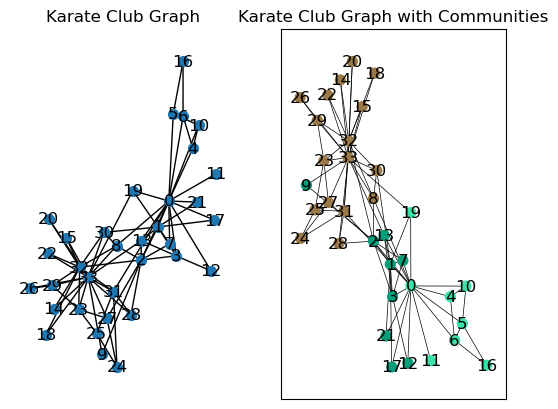

In [1]:
# greedy modularity communities 方法（CNM算法）
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
import matplotlib.pyplot as plt
from random import randint

G = nx.karate_club_graph()
plt.subplot(121)
nx.draw(G, node_size=50, with_labels=True)
plt.title('Karate Club Graph')

# 使用 greedy modularity（CNM）算法进行社团检测
partitions = greedy_modularity_communities(G)
print("网络社团为：", partitions)

# 计算模块度
Q = nx.community.modularity(G, partitions)
print("模块度Q=", Q)

colors = ["" for x in range(G.number_of_nodes())]
counter = 0
for partition in partitions:
    color = "#%06X" % randint(0, 0xFFFFFF)
    counter += 1

    for node in partition:
        colors[node] = color

print("社团数量为：", counter)
plt.axis("off")
plt.subplot(122)
nx.draw_networkx(G, node_size=50, with_labels=True, width=0.5, node_color=colors)
plt.title('Karate Club Graph with Communities')
plt.show()


网络社团为： [{16, 4, 5, 6, 10}, {0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21}, {8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33}]
模块度Q= 0.4345214669889994
社团数量： 3


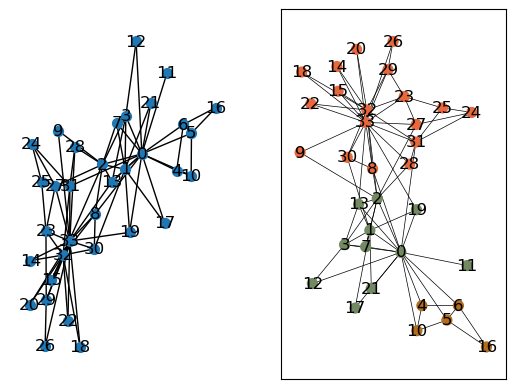

In [3]:
# Louvain 算法
import networkx as nx
import networkx.algorithms.community as nx_comm
import matplotlib.pyplot as plt
from random import randint

G = nx.karate_club_graph()
plt.subplot(121)
nx.draw(G, node_size=50, with_labels=True)

# 使用 Louvain 算法进行社团检测
partition = nx_comm.louvain_communities(G)
print("网络社团为：", partition)

# 计算模块度
Q = nx_comm.modularity(G, partition)
print("模块度Q=", Q)

# 初始化颜色列表，用于存储每个节点的颜色
colors = ["" for _ in range(G.number_of_nodes())]

# 为每个社团分配随机颜色
for com in partition:
    # 生成一个随机的十六进制颜色代码（RGB）
    color = "#%06X" % randint(0, 0xFFFFFF)
    # 为当前社团的所有节点分配相同的颜色
    for node in com:
        colors[node] = color

print("社团数量：", len(partition))
plt.axis("off")
plt.subplot(122)
nx.draw_networkx(G, node_size=50, with_labels=True, width=0.5, node_color=colors)
plt.show()


网络社团为： [{0, 1, 3, 4, 7, 10, 11, 12, 13, 17, 19, 21, 24, 25, 31}, {32, 33, 2, 8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 28, 29, 30}, {16, 5, 6}]
模块度Q= 0.30948632896684847
社团数量为： 3


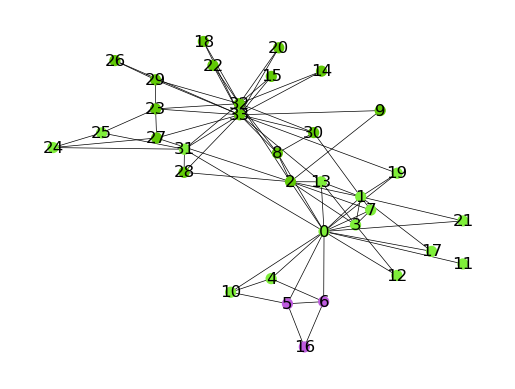

In [7]:
# 利用标签传播算法对空手道俱乐部网络进行社团检测
# 参考：Near linear time algorithm to detect community structures in large-scale networks
import networkx as nx
import networkx.algorithms.community as nx_comm
import matplotlib.pyplot as plt
from random import randint

G = nx.karate_club_graph()

# 标签传播算法进行社区检测
partition = list(nx.community.label_propagation_communities(G))
print("网络社团为：", partition)

Q = nx_comm.modularity(G, partition)
print("模块度Q=", Q)

colors = ["" for _ in range(G.number_of_nodes())]
counter = 0
for com in partition:
    color = "#%06X" % randint(0, 0xFFFFFF)
    counter += 1
    for node in list(com):
        colors[node] = color

print("社团数量为：", len(partition))
plt.axis("off")
nx.draw_networkx(G, node_size=50, with_labels=True, width=0.5, node_color=colors)
plt.show()


In [ ]:
# girvan_newman(GN) 算法求模块度
import networkx as nx
from networkx.algorithms import community
import itertools
import matplotlib.pyplot as plt
from random import randint

# 创建随机图
G = nx.erdos_renyi_graph(100, 0.08)

# 设置最大社团数量
k = 10

# 使用 Girvan-Newman 算法进行社团划分
comp = community.girvan_newman(G)

# 取社团数量小于等于 k 的划分结果
limited = itertools.takewhile(lambda c: len(c) <= k, comp)

# 存储最后一次划分结果
final_communities = None
for communities in limited:
    final_communities = list(sorted(c) for c in communities)

if final_communities:
    print("网络社团为：", final_communities)

    # 计算模块度
    Q = community.modularity(G, final_communities)
    print("模块度 Q =", Q)

    colors = ["" for _ in range(G.number_of_nodes())]
    for i, com in enumerate(final_communities):
        color = "#%06X" % randint(0, 0xFFFFFF)
        for node in com:
            colors[node] = color

    nx.draw_networkx(G, node_size=50, with_labels=True, width=0.5, node_color=colors)
    plt.show()


In [ ]:
# facebook 网络的社团划分
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from networkx.algorithms import community
import networkx.algorithms.community as nx_comm
from random import randint

facebook = pd.read_csv(
    'facebook_combined.txt.gz',
    compression='gzip',
    sep=' ',
    names=['start_node', 'end_node']
)

G = nx.from_pandas_edgelist(facebook, 'start_node', 'end_node')

colors = ["" for _ in range(G.number_of_nodes())]
partitions = nx_comm.louvain_communities(G)
for partition in partitions:
    color = "#%06X" % randint(0, 0xFFFFFF)
    for node in list(partition):
        colors[node] = color

Q = community.modularity(G, partitions)
print("模块度 Q =", Q)

print("社团数量为：", len(partitions))
plt.axis("off")
nx.draw_networkx(G, node_size=10, with_labels=False, width=0.15, node_color=colors)
plt.show()
